In [73]:
import os
import torch
import torch.nn as nn
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, ConcatDataset, SubsetRandomSampler
from torchvision import transforms

from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset Preparation

In [74]:
def show(dataset, num_examples=5):
    fig, axes = plt.subplots(1, num_examples, figsize=(12, 3))

    for i in range(num_examples):
        index = torch.randint(len(dataset), size=(1,)).item()
        image, label = dataset[index]

        axes[i].imshow(image.squeeze(), cmap='gray')
        axes[i].set_title(f"Label: {label}")
        axes[i].axis('off')

    plt.show()

In [75]:
dataset_train_part = MNIST(os.getcwd(), download=True, transform=transforms.ToTensor(), train=True)
dataset_test_part = MNIST(os.getcwd(), download=True, transform=transforms.ToTensor(), train=False)

Examples from the Training Set: 


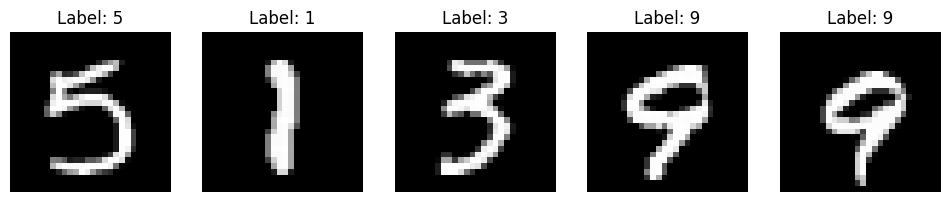


Examples from the Validation Set: 


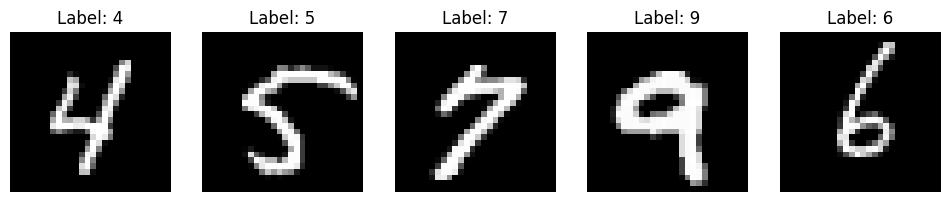

In [76]:
print("Examples from the Training Set: ")
show(dataset_train_part)

print("\nExamples from the Validation Set: ")
show(dataset_test_part)

# Convolutional Neural Nets

In [77]:
class SimpleConvNet(nn.Module):
    def __init__(self):
        super(SimpleConvNet, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 10, kernel_size=3),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(26*26*10, 50),
            nn.ReLU(),
            nn.Linear(50, 20),
            nn.ReLU(),
            nn.Linear(20, 10)
        )

    def forward(self, x):
        return self.layers(x)

In [78]:
def train(model, train_loader, optimizer, loss_function, num_epochs):
    for epoch in range(num_epochs):
        print(f'Starting epoch {epoch + 1}')
        current_loss = 0.0

        for i, data in enumerate(train_loader, 0):
            inputs, targets = data
            inputs = torch.tensor(inputs, dtype=torch.float32).to(device)
            targets = torch.tensor(targets, dtype=torch.long).to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_function(outputs, targets)
            loss.backward()
            optimizer.step()
            current_loss += loss.item()

            if i % 500 == 499:
                print(
                    'Loss after mini-batch %5d: %.3f' %
                    (i + 1, current_loss / 500)
                )
                current_loss = 0.0

In [79]:
def test(model, test_loader):
    correct, total = 0, 0

    with torch.no_grad():
        for i, data in enumerate(test_loader, 0):
            inputs, targets = data
            inputs = torch.tensor(inputs, dtype=torch.float32).to(device)
            targets = torch.tensor(targets, dtype=torch.long).to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    accuracy = 100.0 * correct / total
    print(f'Accuracy: {accuracy:.2f}%')
    return accuracy

# K-Fold Validation

In [80]:
def k_fold_cross_validation(k_folds, num_epochs, loss_function):
    
    results = {}
    dataset = ConcatDataset([dataset_train_part, dataset_test_part])
    kfold = KFold(n_splits=k_folds, shuffle=True)

    for fold, (train_ids, test_ids) in enumerate(kfold.split(dataset)):
        print(f'FOLD {fold}')
        print('---------------------------------')

        train_subsampler = SubsetRandomSampler(train_ids)
        test_subsampler = SubsetRandomSampler(test_ids)

        trainloader = DataLoader(dataset,batch_size=10,sampler=train_subsampler)
        testloader = DataLoader(dataset,batch_size=10,sampler=test_subsampler)

        net = SimpleConvNet().to(device)
        # net.apply(reset_weights)
        optimizer = torch.optim.Adam(net.parameters(),lr=0.001)

        train(net, trainloader, optimizer, loss_function, num_epochs)

        print('Training process has finished. Saving trained model.')
        print('Starting tesing')

        save_path = f'./model-fold-{fold}.pth'
        torch.save(net.state_dict(), save_path)

        accuracy = test(net, testloader)
        results[fold] = accuracy
        print('-------------------------')

    return results

def print_results(results):
    print(f'K-FOLD CROSS VALIDATION RESULTS FOR {len(results)} FOLDS')
    print('----------------------------------')

    total_accuracy = sum(results.values())
    average_accuracy = total_accuracy / len(results)

    for key, value in results.items():
        print(f'Fold {key}: {value:.2f}%')
    
    print(f"Average accuracy: {average_accuracy:.2f}%")


In [81]:
def main():
    k_folds = 5
    num_epochs = 1
    loss_function = nn.CrossEntropyLoss()

    results = k_fold_cross_validation(k_folds, num_epochs, loss_function)
    print_results(results)

In [89]:
main()

FOLD 0
---------------------------------
Starting epoch 1


C:\Users\72998\AppData\Local\Temp\ipykernel_9332\2746225255.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(inputs, dtype=torch.float32).to(device)
C:\Users\72998\AppData\Local\Temp\ipykernel_9332\2746225255.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  targets = torch.tensor(targets, dtype=torch.long).to(device)


Loss after mini-batch   500: 0.724
Loss after mini-batch  1000: 0.354
Loss after mini-batch  1500: 0.290
Loss after mini-batch  2000: 0.250
Loss after mini-batch  2500: 0.213
Loss after mini-batch  3000: 0.203
Loss after mini-batch  3500: 0.175
Loss after mini-batch  4000: 0.167
Loss after mini-batch  4500: 0.167
Loss after mini-batch  5000: 0.143
Loss after mini-batch  5500: 0.114
Training process has finished. Saving trained model.
Starting tesing


C:\Users\72998\AppData\Local\Temp\ipykernel_9332\483722209.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(inputs, dtype=torch.float32).to(device)


Accuracy: 96.65%
-------------------------
FOLD 1
---------------------------------
Starting epoch 1
Loss after mini-batch   500: 0.914
Loss after mini-batch  1000: 0.356
Loss after mini-batch  1500: 0.313
Loss after mini-batch  2000: 0.252
Loss after mini-batch  2500: 0.226
Loss after mini-batch  3000: 0.173
Loss after mini-batch  3500: 0.168
Loss after mini-batch  4000: 0.172
Loss after mini-batch  4500: 0.156
Loss after mini-batch  5000: 0.131
Loss after mini-batch  5500: 0.143
Training process has finished. Saving trained model.
Starting tesing
Accuracy: 96.36%
-------------------------
FOLD 2
---------------------------------
Starting epoch 1
Loss after mini-batch   500: 1.030
Loss after mini-batch  1000: 0.446
Loss after mini-batch  1500: 0.373
Loss after mini-batch  2000: 0.311
Loss after mini-batch  2500: 0.285
Loss after mini-batch  3000: 0.249
Loss after mini-batch  3500: 0.256
Loss after mini-batch  4000: 0.224
Loss after mini-batch  4500: 0.191
Loss after mini-batch  5000: 